In [1]:
import gsw
import numpy as np
import netCDF4 as netcdf
from matplotlib import pyplot as plt
from scipy import ndimage
from datetime import datetime, timedelta
import pandas as pd
from scipy import stats
import xarray as xr

from scipy.signal import savgol_filter # smooths the data

import ecco_v4_py as ecco
import os
import glob
import pickle

In [2]:
# all helper functions are stored in v4r5_wmt_functions.py
import v4r5_wmt_func

In [3]:
p = 2000

#### NEED TO UNCOMMENT AND RUN EACH OF THESE rhomax, rhomin RANGES TO GENERATE NECESSARY OUTPUT TO USE IN ____.ipynb ####
# rhomax, rhomin = 1036.79, 1037.25 # si formation
# rhomax, rhomin = 1035.95, 1036.7 # si melt
rhomax, rhomin = 1035.6, 1037.25 # whole wmt analysis range

nlevs = 2
rholevs = np.linspace(rhomax, rhomin, nlevs)

In [4]:
v4r5_fp = '/export/data1/szhang6/ECCO2/LLC90/v4r5_monthly/'

## ECCO variable names + descriptions (used in the next cell)
[Freshwater file](https://podaac.jpl.nasa.gov/dataset/ECCO_L4_FRESH_FLUX_05DEG_MONTHLY_V4R4#)
- Freshwater flux:
    - EXFempmr: Open ocean net surface freshwater flux from precipitation, evaporation, and runoff (m/s)
- Sea ice:
    - SIdHbOCN: HEFF rate of change by ocean ice flux (m/s)
    - SIdSbOCN: HSNOW rate of change by ocean ice flux (m/s)

[TS file](https://podaac.jpl.nasa.gov/dataset/ECCO_L4_TEMP_SALINITY_05DEG_MONTHLY_V4R4)
- THETA: Potential temperature (deg C)
- SALT: Salinity (1e-3)

[Heat flux file](https://podaac.jpl.nasa.gov/dataset/ECCO_L4_HEAT_FLUX_05DEG_MONTHLY_V4R4#)
- oceQnet: Net heat flux into the ocean surface (W/m2)

In [5]:
use_iters = []

pattern = "EXFempmr.*.data" 

# Construct the full path pattern
full_path_pattern = os.path.join(v4r5_fp, pattern)

# List files matching the pattern
matching_files = glob.glob(full_path_pattern)
hour_intervals = [file_path[-15:-5] for file_path in matching_files]
print(f'first hour interval: {hour_intervals[0]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[0])})')
print(f'last hour interval: {hour_intervals[-1]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[-1])})')
print('num iterations saved: ', len(hour_intervals))

first hour interval: 0000000732 (1992-01-31 00:00:00)
last hour interval: 0000288540 (2024-11-30 00:00:00)
num iterations saved:  395


In [6]:
var_pop = ['sst','sss','sfc_hflux_coupler','pme_river','melt']
ecco_vars = ['THETA', 'SALT', 'oceQnet', 'EXFempmr', 'oceFWflx', 'SIatmFW']

file_vars = {'sst': 'THETA',
            'sss': 'SALT',
            'sfc_hflux_coupler': 'oceQnet',
            'pme_river': 'oceFWflx',
            'melt': ['oceFWflx', 'SIatmFW']}

# THIS VERSION ASSUMES OUTPUTS ARE ALREADY MONTHLY MEANS
monthly_mean = {}
for ecco_varname in ecco_vars:
    variable_monthly_means = {}
    
    for hr in hour_intervals:
        date = v4r5_wmt_func.iteration_to_date(hr)
        yr_month = f'{date.year}_{date.month}'
        daily_vals = v4r5_wmt_func.load_reproject_values(ecco_varname, hr)
        variable_monthly_means[yr_month] = daily_vals

    monthly_mean[ecco_varname] = variable_monthly_means

monthly_mean.keys()

dict_keys(['THETA', 'SALT', 'oceQnet', 'EXFempmr', 'oceFWflx', 'SIatmFW'])

In [7]:
R = {}
for og_var_name, ecco_varname in file_vars.items():
    if og_var_name == 'melt':
        incl_si, no_si = ecco_varname[0], ecco_varname[1]
        diff_arrays = [
            a - b
            for a, b in zip(
                monthly_mean[incl_si].values(),
                monthly_mean[no_si].values()
            )]
        # diff_arrays = monthly_mean[incl_si].values - monthly_mean[no_si].values()
        R[og_var_name] = diff_arrays
    else:
        R[og_var_name] = list(monthly_mean[ecco_varname].values())
R.keys()

dict_keys(['sst', 'sss', 'sfc_hflux_coupler', 'pme_river', 'melt'])

## Load ECCO grid

In [8]:
grid_size = 1
grid_size_str = str(grid_size).replace('.','')
basin_file = netcdf.Dataset(f'basin_mask_regridded_ecco_v4r5_{grid_size_str}deg.nc')
basins = basin_file.variables['BASIN_MASK'][:]
basins.shape

(180, 360)

(180, 360) (180, 360) (180, 360)

Plot of native grid area:


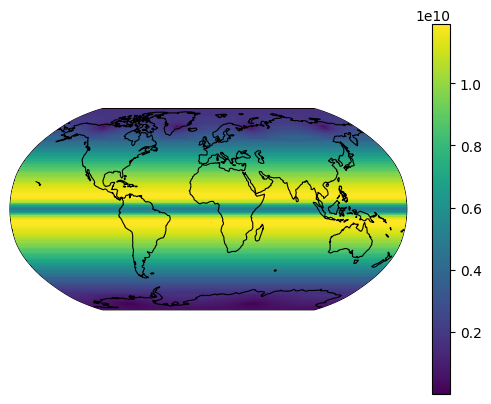

In [9]:
########## using .data grid files
grid_fp = '/home/dmenemen/eady-data1/grid/ECCO_V4r5/'
ecco_XC = ecco.read_llc_to_tiles(grid_fp, 'XC.data', less_output=True)
ecco_YC = ecco.read_llc_to_tiles(grid_fp, 'YC.data', less_output=True)
ecco_RAC = ecco.read_llc_to_tiles(grid_fp, 'RAC.data', less_output=True)
projected_dummy_area = ecco.plot_proj_to_latlon_grid(ecco_XC, ecco_YC, ecco_RAC, show_colorbar=True, show_land=False, dx=grid_size, dy=grid_size);

X, Y = projected_dummy_area[4], projected_dummy_area[5]

with open(f'/home/szhang6/wmt/ecco_v4r5_{grid_size_str}deg_areas.pkl', 'rb') as f:
    area = pickle.load(f)

print(X.shape, Y.shape, area.shape)
print('\nPlot of native grid area:')

In [10]:
SO = basins ==1
# TOT = basins > 0

# hems = ['SO']
# hem = [SO]

## Calculate WMT

In [11]:
a,b = SO.shape

Nt = len(R['sst']) #12
TRANS = dict()
TRANS_SI = dict()
H = dict()
FW = dict()
AREA = dict()

trans = np.zeros((Nt,2,len(rholevs)-1))
trans_si = np.zeros((Nt,2,len(rholevs)-1))

# afield = np.zeros((Nt,2,len(rholevs)-1))
rho = np.zeros((Nt,a,b))
alpha  = np.zeros((Nt,a,b))
beta = np.zeros((Nt,a,b))

t = np.zeros((Nt,a,b))
s = np.zeros((Nt,a,b))

area1 = area.copy()

Fdens_heat = np.zeros((Nt,a,b))
Fdens_salt = np.zeros((Nt,a,b))
Fdens_si = np.zeros((Nt,a,b))

In [12]:
cp = 3994 # specific heat at constant pressure
mask = SO
    
for f in range(Nt):     
    s = gsw.SA_from_SP(np.squeeze(R[var_pop[1]][f]) *  SO,1,X,Y)  # sss
    t = gsw.CT_from_pt(s, np.squeeze(R[var_pop[0]][f]) *  SO)  # sst
    hf = np.squeeze(R[var_pop[2]][f]) *  SO # heat flux
    fw = np.squeeze(R[var_pop[3]][f]) *  SO  # var_pop[3] = 'pme_river' -> p - e + river -> freshwater flux?
    si = np.squeeze(R[var_pop[4]][f]) *  SO 
    hem_area = area1 *  SO

    # gsw.rho_alpha_beta calculates in-situ density, thermal expansion coefficient, and saline contraction coefficient 
    # of seawater from Absolute Salinity and Conservative Temperature
    rho[f,:,:], alpha[f,:,:], beta[f,:,:] = gsw.rho_alpha_beta(s,t,p) # p = 2000, defined in the beginning

    # these are the terms in equation 6
    Fdens_heat[f,:,:] =  (- alpha[f,:,:] / cp * hf)*hem_area # first term
    Fdens_salt[f,:,:] =  (- beta[f,:,:] /1000 * s * fw * 1032)*hem_area # second term (rho0 = 1032, rhoFW = 1000)
    Fdens_si[f,:,:] =  (- beta[f,:,:] /1000 * s * si * 1032)*hem_area # second term, but just SI contribution (rho0 = 1032, rhoFW = 1000)

    # use equation 5 to calculate WMT
    trans[f,:,:] = v4r5_wmt_func.calculate_transformation_rate(rho[f,:,:], hem_area, SO, rholevs,Fdens_heat[f,:,:], Fdens_salt[f,:,:])
    trans_si[f,:,:] = v4r5_wmt_func.calculate_transformation_rate(rho[f,:,:], hem_area, SO, rholevs,Fdens_heat[f,:,:], Fdens_si[f,:,:])
   
TRANS['SO']    = np.nanmean(trans, axis=0)
TRANS_SI['SO'] = np.nanmean(trans_si, axis=0)

## Load SIE

In [13]:
ecco_grid = xr.open_dataset('/home/szhang6/wmt/ECCO_GRID_v4r5.nc')
ss = 0 # southern ocean
ic = 0.15 # sea ice extent

hc5 = ecco_grid.hFacC
rc5 = ecco_grid.rA
yc5 = ecco_grid.YC

so_tiles = [0,3,9,12, 1, 4, 8, 11]

hc5_so = hc5.isel(tile=so_tiles)
rc5_so = rc5.isel(tile=so_tiles)
yc_so = yc5.isel(tile=so_tiles)

ecco_monthly_area_global = {}

for hr in hour_intervals:
    date_str = str(hr).zfill(10)
    fn = f'SIarea.{date_str}.data'
    month_global_area = ecco.read_llc_to_tiles(v4r5_fp, fn, less_output=True)

    save_date = v4r5_wmt_func.iteration_to_date(date_str).strftime("%m-%Y")
    ecco_monthly_area_global[save_date] = month_global_area

extent_threshold = 0.15
monthly_sie_sia = {}
for month, vals in ecco_monthly_area_global.items():
    so_ecco = vals[so_tiles]
    sia = np.sum(so_ecco * rc5_so * hc5_so.sel(k=0)).item()
    
    so_ecco_copy = so_ecco.copy()
    so_ecco_copy[so_ecco_copy < extent_threshold] = 0
    sie = np.sum(so_ecco_copy * rc5_so).item()
    
    monthly_sie_sia[month] = [sia, sie]

ecco_areas_df = pd.DataFrame.from_dict(monthly_sie_sia, orient='index', columns=['sia', 'sie'])
ecco_areas_df = ecco_areas_df.reset_index().rename(columns={'index': 'date'})
ecco_areas_df['month'] = ecco_areas_df['date'].str[:2].astype(int)
ecco_areas_df

,date,sia,sie,month
0,01-1992,2.387398e+12,2.242112e+12,1
1,02-1992,1.574217e+12,1.535069e+12,2
2,03-1992,2.479388e+12,2.400732e+12,3
3,04-1992,5.356651e+12,5.284752e+12,4
4,05-1992,8.304037e+12,8.222703e+12,5
...,...,...,...,...
390,07-2024,1.352186e+13,1.345753e+13,7
391,08-2024,1.560691e+13,1.554165e+13,8
392,09-2024,1.647266e+13,1.641051e+13,9
393,10-2024,1.597932e+13,1.593246e+13,10


## Calculate surface buoyancy flux ($F_b$) and outcrop area ($A$)

In [14]:
SO_grid_areas = area.copy() * SO
SO_grid_areas = SO_grid_areas.filled(np.nan)

In [15]:
F = (Fdens_heat + Fdens_salt) / SO_grid_areas
F.shape

/tmp/ipykernel_1162925/4001038691.py:1: RuntimeWarning: invalid value encountered in divide
  F = (Fdens_heat + Fdens_salt) / SO_grid_areas


(395, 180, 360)

In [16]:
F_copy = F.copy()

rho_SO_monthly = rho * SO

# Initialize array: (395 months, 300 density classes)
monthly_F_sums = np.zeros((len(rho_SO_monthly), len(rholevs) - 1))
monthly_A_sums = np.zeros((len(rho_SO_monthly), len(rholevs) - 1))

for i, monthly_rho in enumerate(rho_SO_monthly):
    for j in range(len(rholevs) - 1):
        dens_range = [rholevs[j], rholevs[j + 1]]
        
        # Create mask for this density class
        mask = (np.isnan(monthly_rho) | (monthly_rho < dens_range[0]) | (monthly_rho >= dens_range[1]))
        
        # Create temporary copies for this density class
        F_temp = F_copy[i].copy()
        F_temp[mask] = np.nan

        A_temp = SO_grid_areas.copy()
        A_temp[mask] = np.nan
    
        area_densclass = np.nansum(A_temp)
        monthly_A_sums[i, j] = area_densclass
        monthly_F_sums[i, j] = np.nansum(F_temp * A_temp) / area_densclass
        
monthly_F_sums.shape, monthly_A_sums.shape

((395, 1), (395, 1))

In [17]:
A = monthly_A_sums
A_bar = np.nanmean(A, axis=0)
A_prime = A - A_bar

F_bar = np.nanmean(monthly_F_sums, axis=0)
F_prime = monthly_F_sums - F_bar

print(f"F shape: {F.shape}")
print(f"F_bar shape: {F_bar.shape}")
print(f"F' shape: {F_prime.shape}")

print()

print(f"A shape: {A.shape}")
print(f"A_bar shape: {A_bar.shape}")
print(f"A' shape: {A_prime.shape}")

F shape: (395, 180, 360)
F_bar shape: (1,)
F' shape: (395, 1)

A shape: (395, 1)
A_bar shape: (1,)
A' shape: (395, 1)


## Calculate correlations, plot

In [18]:
ecco_areas_df_wyear = ecco_areas_df.copy()
ecco_areas_df_wyear['year'] = pd.to_numeric(ecco_areas_df_wyear['date'].str[-4:])
years = ecco_areas_df_wyear['year']
vmin, vmax = years.min(), years.max()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [19]:
monthly_sie = ecco_areas_df['sie'].values / 1e6 / 1e6
monthly_Aprime_over_Abar = (A_prime[:, 0] / A_bar[0]).flatten()
monthly_Fprime_over_Fbar = (F_prime[:, 0] / F_bar[0]).flatten()

##### F_b' vs. A' #####
# x = np.asarray(monthly_Aprime_over_Abar)
# y = np.asarray(monthly_Fprime_over_Fbar)

slope, intercept, r, p, _ = stats.linregress(monthly_Aprime_over_Abar, monthly_Fprime_over_Fbar)

# SAVE FOR np.savez LATER:
Aprime_Fprime_overalls = np.array([slope, r, p])  # [slope, correlation coefficient, pvalue]


##### A', F_b' vs. SIE #####
slope_A, intercept_A, r_A, p_A, _ = stats.linregress(monthly_sie, monthly_Aprime_over_Abar)
slope_F, intercept_F, r_F, p_F, _ = stats.linregress(monthly_sie, monthly_Fprime_over_Fbar)

# SAVE FOR np.savez LATER:
Aprime_SIE_overalls = np.array([slope_A, r_A, p_A])  # [slope, correlation coefficient, pvalue]
Fprime_SIE_overalls = np.array([slope_F, r_F, p_F])  # [slope, correlation coefficient, pvalue]

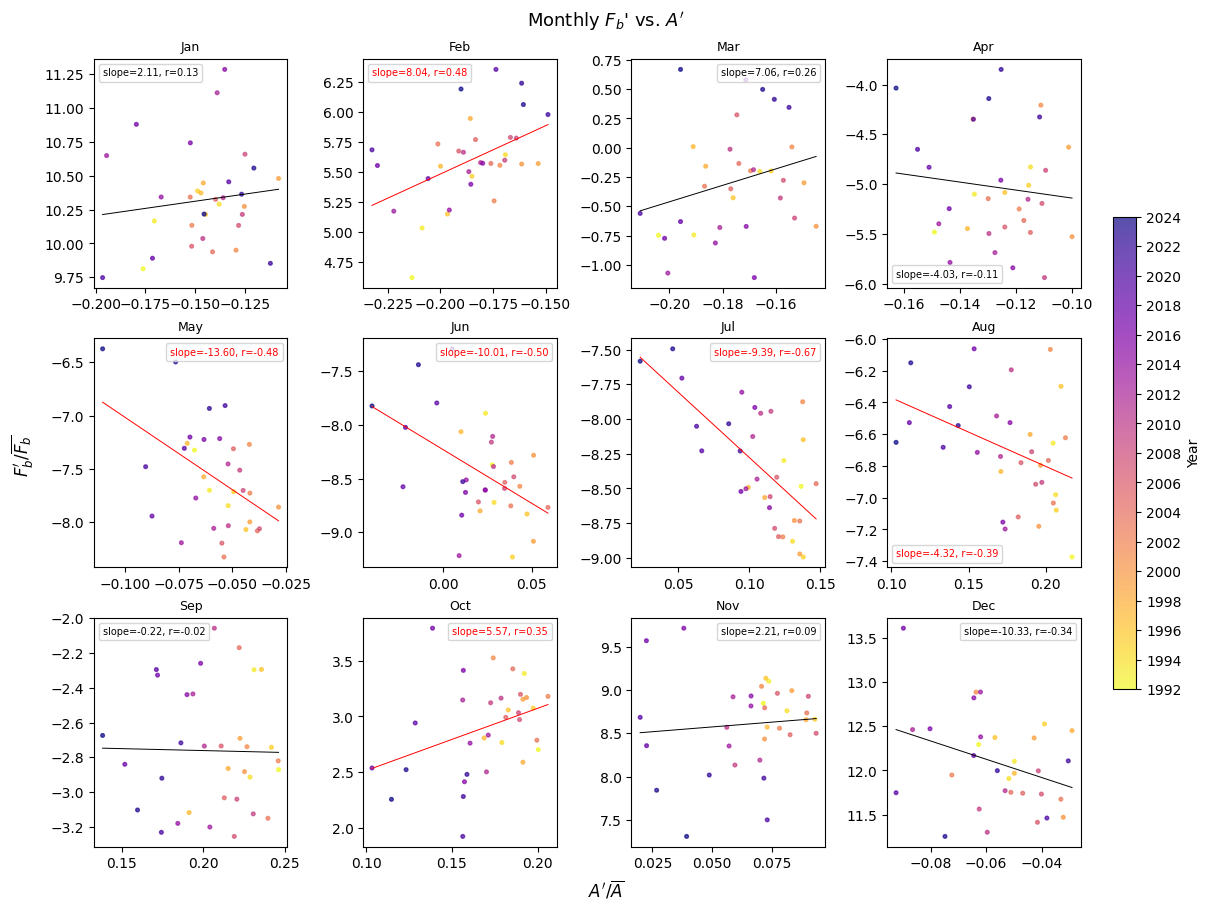

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
axes = axes.flatten()

# SAVE FOR np.savez LATER:
Aprime_Fprime_monthly_slopes = {}
Aprime_Fprime_monthly_rs = {}
Aprime_Fprime_monthly_pvals = {}

for m in range(1, 13):
    ax = axes[m - 1]
    mask = ecco_areas_df_wyear['month'] == m
    x = monthly_Aprime_over_Abar[mask]
    y = monthly_Fprime_over_Fbar[mask]
    yr = years[mask].values

    sc = ax.scatter(x, y, c=yr, cmap='plasma_r', s=7, alpha=0.7,
                    vmin=vmin, vmax=vmax)

    slope, intercept, r, p, _ = stats.linregress(x, y)
    # SAVE FOR np.savez LATER: 
    Aprime_Fprime_monthly_slopes[m] = slope
    Aprime_Fprime_monthly_rs[m] = r
    Aprime_Fprime_monthly_pvals[m] = p
    
    color = 'red' if p < 0.05 else 'black'
    x_fit = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=0.7)
    ax.plot([], [], color=color, label=f'slope={slope:.2f}, r={r:.2f}')
    ax.legend(fontsize=7, handlelength=0, handletextpad=0,
              labelcolor=color, frameon=True)
    ax.set_title(month_names[m - 1], fontsize=9)
    
fig.suptitle(r"Monthly $F_b$' vs. $A'$", fontsize=13)
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', pad=0.02, shrink=0.6,
                    ticks=np.arange(vmin, vmax+1, 2))
cbar.set_label('Year')
fig.supxlabel(r"$A'/\overline{A}$")
fig.supylabel(r"$F_b'/\overline{F_b}$")
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1162925/1779462672.py:31: SyntaxWarning: invalid escape sequence '\o'
  if "\overline{A}" in ylabel: # Aprime vs. SIE stats
/tmp/ipykernel_1162925/1779462672.py:58: UserWarning: Adding colorbar to a different Figure <Figure size 1200x900 with 12 Axes> than <Figure size 1200x900 with 13 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, ax=axes, orientation='vertical', pad=0.02, shrink=0.6,


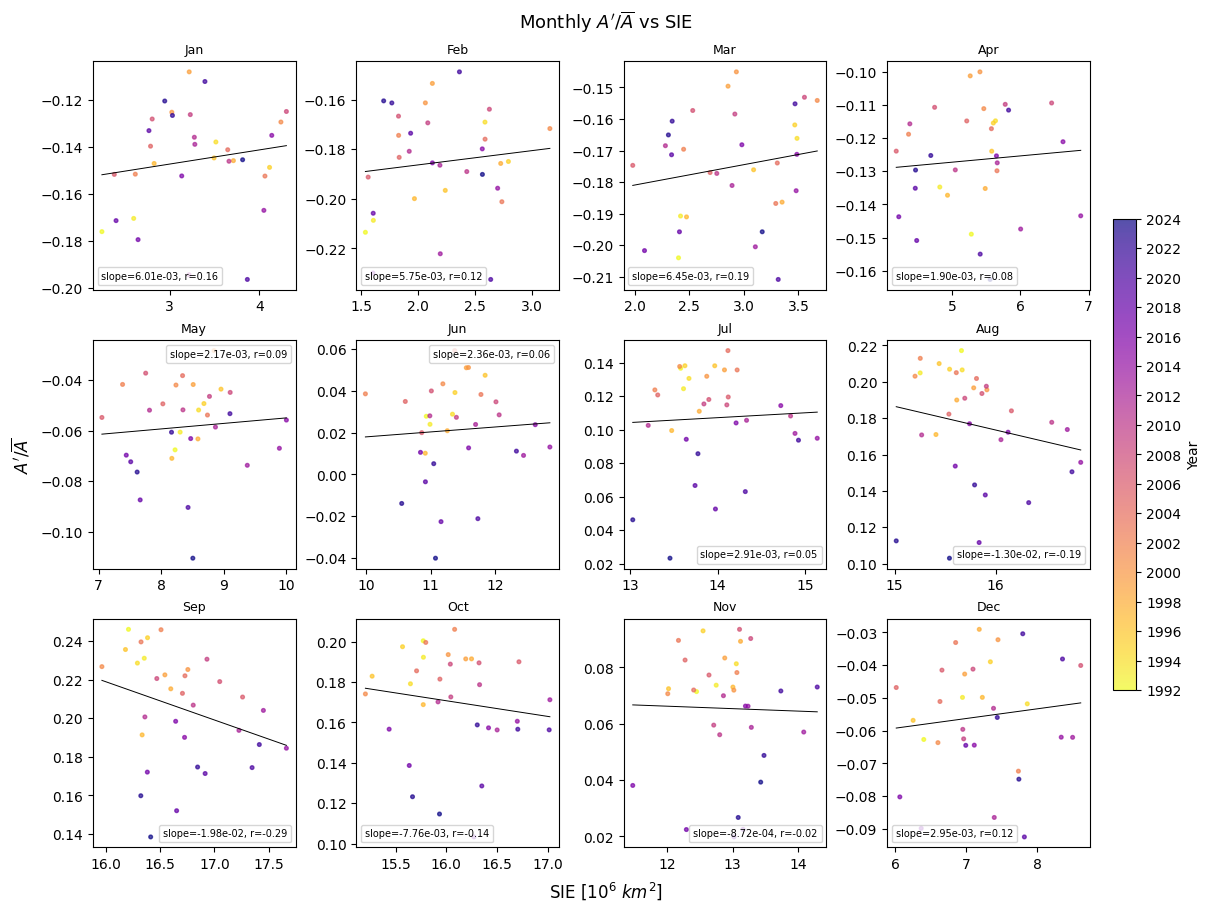

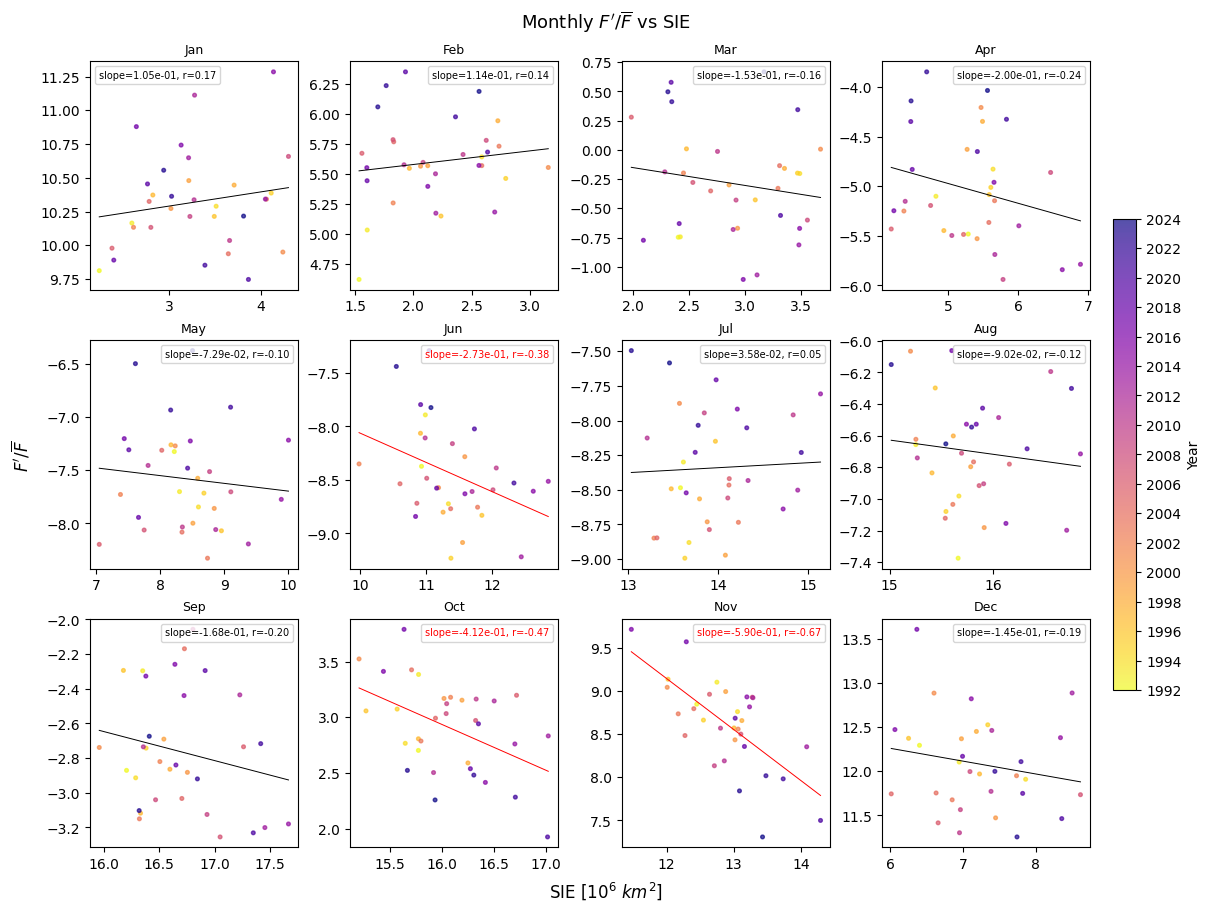

In [21]:
fig1, axes1 = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
axes1 = axes1.flatten()
fig2, axes2 = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
axes2 = axes2.flatten()

# SAVE FOR np.savez LATER:
Aprime_SIE_monthly_slopes = {}
Aprime_SIE_monthly_rs = {}
Aprime_SIE_monthly_pvals = {}
Fprime_SIE_monthly_slopes = {}
Fprime_SIE_monthly_rs = {}
Fprime_SIE_monthly_pvals = {}

for m in range(1, 13):
    mask = ecco_areas_df_wyear['month'] == m
    sie = monthly_sie[mask]
    aprime = monthly_Aprime_over_Abar[mask]
    fprime = monthly_Fprime_over_Fbar[mask]
    yr = years[mask].values

    for ax, y, ylabel in [
        (axes1[m-1], aprime, r"$A'/\overline{A}$"),
        (axes2[m-1], fprime, r"$F_b'/\overline{F_b}$"),
    ]:
        sc = ax.scatter(sie, y, c=yr, cmap='plasma_r', s=7, alpha=0.7,
                        vmin=vmin, vmax=vmax)

        slope, intercept, r, p, _ = stats.linregress(sie, y)

        # SAVE FOR np.savez LATER:
        if "\overline{A}" in ylabel: # Aprime vs. SIE stats
            Aprime_SIE_monthly_slopes[m] = slope
            Aprime_SIE_monthly_rs[m] = r
            Aprime_SIE_monthly_pvals[m] = p
            
        else: # Fprime vs. SIE stats
            Fprime_SIE_monthly_slopes[m] = slope
            Fprime_SIE_monthly_rs[m] = r
            Fprime_SIE_monthly_pvals[m] = p

        color = 'red' if p < 0.05 else 'black'
        x_fit = np.linspace(sie.min(), sie.max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=0.7)
        ax.plot([], [], color=color, label=f'slope={slope:.2e}, r={r:.2f}')
        ax.legend(fontsize=7, handlelength=0, handletextpad=0,
                  labelcolor=color, frameon=True)
        ax.set_title(month_names[m-1], fontsize=9)

# shared colorbar
for fig, axes, title in [
    (fig1, axes1, r"Monthly $A'/\overline{A}$ vs SIE"),
    (fig2, axes2, r"Monthly $F'/\overline{F}$ vs SIE"),
]:
    fig.suptitle(title, fontsize=13)
    fig.supxlabel('SIE [$10^6~km^2$]')
    y_label_txt = title[-24:-7]
    fig.supylabel(y_label_txt)
    cbar = fig.colorbar(sc, ax=axes, orientation='vertical', pad=0.02, shrink=0.6,
                        ticks=np.arange(vmin, vmax+1, 2))
    cbar.set_label('Year')

plt.show()

# Save variables

In [22]:
if rhomin == 1037.25:
    if rhomax == 1035.6: # whole SIZ
        file_savename = 'slopes_rs_wholeSIZ.npz'
    else: # formation region
        file_savename = 'slopes_rs_formation.npz'
elif rhomax == 1035.95: # melt region
    file_savename = 'slopes_rs_melt.npz'

assert 'file_savename' in locals()

np.savez(file_savename,
         Aprime_Fprime_monthly_slopes = Aprime_Fprime_monthly_slopes, # {1: slope_Jan, 2: slope_Feb, ...}
         Aprime_Fprime_monthly_rs = Aprime_Fprime_monthly_rs, # {1: r_Jan, 2: r_Feb, ...}
         Aprime_Fprime_monthly_pvals = Aprime_Fprime_monthly_pvals, # {1: pval_Jan, 2: pval_Feb, ...}
         Aprime_Fprime_overalls = Aprime_Fprime_overalls, # [slope, correlation coefficient, pvalue]

         Aprime_SIE_monthly_slopes = Aprime_SIE_monthly_slopes,
         Aprime_SIE_monthly_rs = Aprime_SIE_monthly_rs,
         Aprime_SIE_monthly_pvals = Aprime_SIE_monthly_pvals,
         Aprime_SIE_overalls = Aprime_SIE_overalls,
         
         Fprime_SIE_monthly_slopes = Fprime_SIE_monthly_slopes,
         Fprime_SIE_monthly_rs = Fprime_SIE_monthly_rs,
         Fprime_SIE_monthly_pvals = Fprime_SIE_monthly_pvals,
         Fprime_SIE_overalls = Fprime_SIE_overalls,

         monthly_sie = monthly_sie,
         monthly_Aprime_over_Abar = monthly_Aprime_over_Abar,
         monthly_Fprime_over_Fbar = monthly_Fprime_over_Fbar,
         months = ecco_areas_df['month'].values
        )